# 03 - Exploratory Data Analysis and Business Insights

This notebook performs exploratory data analysis on the Amsterdam Inside Airbnb market using the cleaned DuckDB warehouse outputs.

The goal is to identify market patterns related to listing supply, room types, pricing, availability, occupancy proxy, host behavior, neighbourhood performance, review scores, and business opportunities.

Each finding includes a business interpretation to make the analysis useful for non-technical stakeholders.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PROJECT_ROOT = Path("..")

WAREHOUSE_PATH = PROJECT_ROOT / "warehouse"
DUCKDB_DATABASE_PATH = WAREHOUSE_PATH / "airbnb_market.duckdb"

FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print("DuckDB database exists:", DUCKDB_DATABASE_PATH.exists())
print("Figures path:", FIGURES_PATH)

DuckDB database exists: True
Figures path: ..\reports\figures


In [6]:
conn = duckdb.connect(database=str(DUCKDB_DATABASE_PATH))

print("Connected to DuckDB successfully.")

Connected to DuckDB successfully.


In [7]:
conn.execute("""
SHOW TABLES
""").fetchdf()

,name
0,dim_host
1,dim_listing
2,dim_neighbourhood
3,fact_listing_market
4,host_portfolio_summary
5,listing_master_final
6,market_overview
7,neighbourhood_summary
8,review_score_summary
9,room_type_summary


In [8]:
market_overview_df = conn.execute("SELECT * FROM market_overview").fetchdf()
room_type_summary_df = conn.execute("SELECT * FROM room_type_summary").fetchdf()
neighbourhood_summary_df = conn.execute("SELECT * FROM neighbourhood_summary").fetchdf()
host_portfolio_summary_df = conn.execute("SELECT * FROM host_portfolio_summary").fetchdf()
review_score_summary_df = conn.execute("SELECT * FROM review_score_summary").fetchdf()

listing_master_df = conn.execute("SELECT * FROM listing_master_final").fetchdf()

print("market_overview:", market_overview_df.shape)
print("room_type_summary:", room_type_summary_df.shape)
print("neighbourhood_summary:", neighbourhood_summary_df.shape)
print("host_portfolio_summary:", host_portfolio_summary_df.shape)
print("review_score_summary:", review_score_summary_df.shape)
print("listing_master_final:", listing_master_df.shape)

market_overview: (1, 14)
room_type_summary: (4, 12)
neighbourhood_summary: (22, 13)
host_portfolio_summary: (5, 11)
review_score_summary: (5, 10)
listing_master_final: (10465, 101)


## 1. Market Overview

This section summarizes the overall Amsterdam Airbnb market using listing counts, host counts, neighbourhood coverage, pricing, availability, review activity, and revenue proxy metrics.

In [9]:
market_overview_df.T

,0
total_listings,1.046500e+04
total_known_hosts,9.104000e+03
total_neighbourhoods,2.200000e+01
avg_listing_price,3.442400e+02
median_listing_price,2.870000e+02
avg_availability_rate,2.615000e-01
avg_occupancy_proxy,7.385000e-01
listings_with_reviews,9.432000e+03
listings_without_reviews,1.033000e+03
total_detailed_reviews,5.451620e+05


### Business Interpretation

The Amsterdam Airbnb dataset contains 10,465 listings across 22 neighbourhoods.  
The market has strong review coverage, with most listings having at least one review.

The average occupancy proxy is higher than the average availability rate, suggesting that many listings are unavailable for a large portion of the calendar year.  
However, this should be interpreted carefully because unavailable dates may include both booked nights and host-blocked dates.

The revenue proxy is useful for comparing segments but should not be treated as actual revenue because the calendar dataset does not include daily price fields.

## 2. Room Type Analysis

This section compares Airbnb listing supply, pricing, availability, occupancy proxy, review scores, and revenue proxy by room type.

In [10]:
room_type_summary_df

,room_type,listing_count,market_share_percentage,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,avg_review_score,total_reviews,total_revenue_proxy,avg_revenue_proxy,listings_missing_price
0,Entire home/apt,8489,81.12,394.62,331.0,0.2133,0.7867,4.87,221489.0,407899491.0,85495.60,3718.0
1,Private room,1929,18.43,203.67,171.0,0.4612,0.5388,4.77,311510.0,55409327.0,33520.46,276.0
2,Hotel room,26,0.25,249.85,227.5,0.7564,0.2436,4.78,6169.0,623504.0,23980.92,0.0
3,Shared room,21,0.20,80.10,52.0,0.7769,0.2231,4.52,5994.0,242392.0,11542.48,0.0


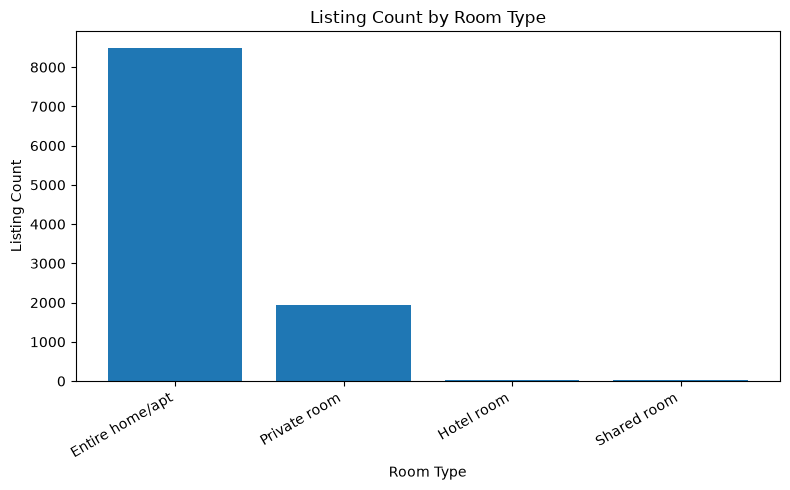

Saved figure to: ..\reports\figures\listing_count_by_room_type.png


In [11]:
plt.figure(figsize=(8, 5))
plt.bar(room_type_summary_df["room_type"], room_type_summary_df["listing_count"])
plt.title("Listing Count by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Listing Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = FIGURES_PATH / "listing_count_by_room_type.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

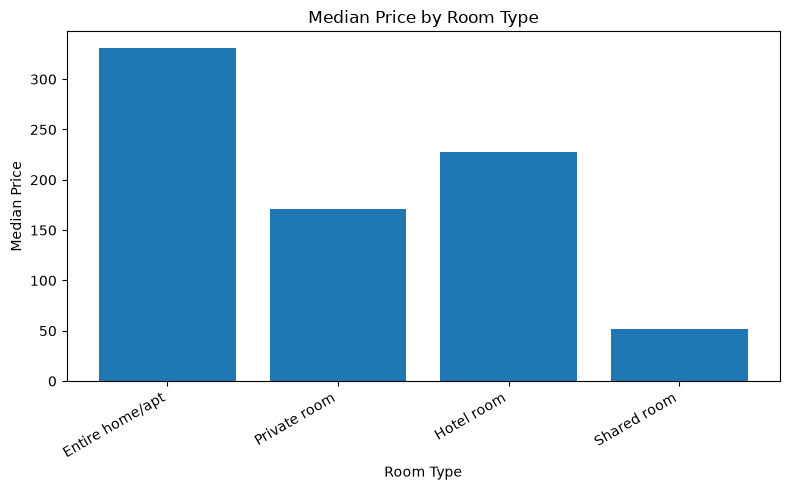

Saved figure to: ..\reports\figures\median_price_by_room_type.png


In [12]:
plt.figure(figsize=(8, 5))
plt.bar(room_type_summary_df["room_type"], room_type_summary_df["median_price"])
plt.title("Median Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Median Price")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = FIGURES_PATH / "median_price_by_room_type.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

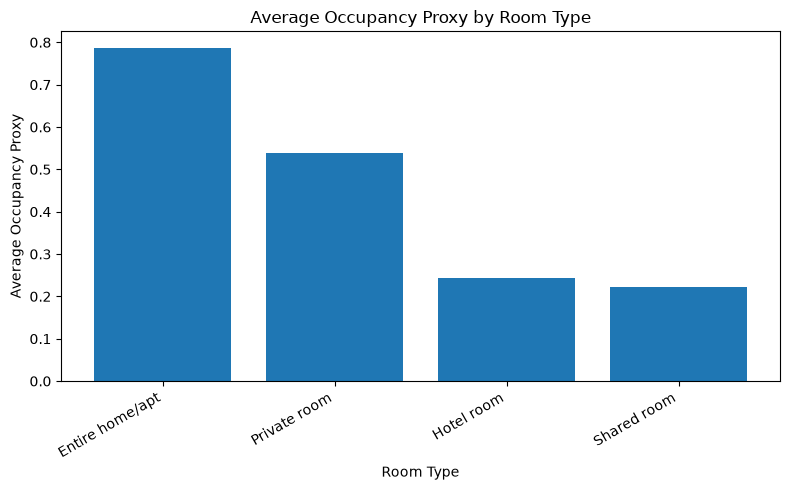

Saved figure to: ..\reports\figures\occupancy_proxy_by_room_type.png


In [13]:
plt.figure(figsize=(8, 5))
plt.bar(room_type_summary_df["room_type"], room_type_summary_df["avg_occupancy_proxy"])
plt.title("Average Occupancy Proxy by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Occupancy Proxy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = FIGURES_PATH / "occupancy_proxy_by_room_type.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Entire home/apartment listings dominate the Amsterdam Airbnb market by listing count and market share.  
They also show higher median pricing and a stronger occupancy proxy compared with private rooms.

This suggests that entire-home listings are the core commercial segment of the Amsterdam short-term rental market.  
Private rooms appear to be a lower-priced segment with higher availability, which may indicate weaker demand or different host usage patterns.

Hotel rooms and shared rooms have very small listing counts, so their metrics should be interpreted cautiously.